<a href="https://colab.research.google.com/github/shehanidilmi52-ctrl/NorthStar-Analytics/blob/main/01_SQL_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("sqldf", quiet=TRUE)
install.packages("ggplot2", quiet=TRUE)
library(sqldf)
library(ggplot2)

base_url <- "https://raw.githubusercontent.com/shehanidilmi52-ctrl/NorthStar-Analytics/main/"

drivers    <- read.csv(url(paste0(base_url, "drivers.csv")))
orders     <- read.csv(url(paste0(base_url, "orders.csv")))
deliveries <- read.csv(url(paste0(base_url, "deliveries.csv")))
complaints <- read.csv(url(paste0(base_url, "complaints.csv")))
vehicles   <- read.csv(url(paste0(base_url, "vehicles.csv")))
customers  <- read.csv(url(paste0(base_url, "customers.csv")))
incidents  <- read.csv(url(paste0(base_url, "incidents.csv")))
hubs       <- read.csv(url(paste0(base_url, "hubs.csv")))

cat("✅ All files loaded from GitHub!\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



✅ All files loaded from GitHub!


In [2]:
result1 <- sqldf("
  SELECT delivery_status,
         COUNT(*) as total,
         ROUND(AVG(fuel_or_charge_cost), 2) as avg_cost,
         ROUND(AVG(customer_rating_post_delivery), 2) as avg_rating
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")
print(result1)

  delivery_status total avg_cost avg_rating
1          OnTime   616    12.68       4.28
2         Delayed   202    13.14       3.11
3          Failed   132    13.15       3.05


In [3]:
result2 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(*) as total_orders,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) as failed,
         SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) as delayed
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failed DESC
")
print(result2)

   pickup_zone total_orders failed delayed
1    RiverSide           66     14      12
2         EAST           78     11      14
3          Ctr           64     11      24
4      Central           55     11      11
5      CENTRAL           55     11      16
6        South           83     10      15
7        north           52      8       6
8         East           78      8      17
9      Airport           67      8      18
10        West           51      7       8
11        WEST           63      7      13
12       North           37      7       6
13       NORTH           46      7       9
14       SOUTH           56      4       7
15   Riverside           53      4      13
16     AIRPORT           46      4      13


In [4]:
result3 <- sqldf("
  SELECT d.driver_id,
         dr.driver_rating,
         dr.years_experience,
         COUNT(*) as total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) as failures,
         ROUND(AVG(d.manual_route_override_count), 2) as avg_overrides
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  ORDER BY failures DESC
  LIMIT 10
")
print(result3)

   driver_id driver_rating years_experience total_deliveries failures
1       D133          3.99               12               12        4
2       D104          3.45               15                7        4
3       D024          3.35                8                8        4
4       D131          4.26                9                9        3
5       D108          4.33               10               11        3
6       D092          4.24               15                5        3
7       D083          4.16               12                9        3
8       D055          5.00               15               10        3
9       D010          3.95                8                7        3
10      D004          4.75               13                9        3
   avg_overrides
1           0.92
2           1.71
3           1.13
4           1.67
5           1.36
6           0.40
7           1.00
8           1.10
9           0.86
10          0.78


In [5]:
result4 <- sqldf("
  SELECT complaint_type,
         severity,
         COUNT(*) as total,
         ROUND(AVG(resolution_days), 2) as avg_resolution_days,
         ROUND(AVG(compensation_amount), 2) as avg_compensation
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY total DESC
")
print(result4)

      complaint_type severity total avg_resolution_days avg_compensation
1              Delay   Medium    56                5.96            18.21
2       MissedPickup   Medium    37                6.16            17.91
3    DriverBehaviour   Medium    31                5.42            15.88
4              Delay      Low    27                6.48             8.16
5           AppIssue   Medium    25                7.36            16.11
6              Delay     High    18               12.44            36.54
7    DriverBehaviour     High    16               13.75            38.39
8       MissedPickup     High    16               11.56            43.07
9           AppIssue      Low    15                6.07            13.25
10          AppIssue     High    13               13.92            34.05
11 SupportExperience   Medium    12                6.17            18.68
12      MissedPickup      Low    11                6.91             8.14
13           Billing   Medium     9                

In [6]:
result5 <- sqldf("
  SELECT v.maintenance_status,
         COUNT(*) as total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) as failures,
         ROUND(AVG(d.fuel_or_charge_cost), 2) as avg_cost
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.maintenance_status
  ORDER BY failures DESC
")
print(result5)

  maintenance_status total_deliveries failures avg_cost
1           InRepair              254       77    12.90
2             Active              542       45    12.87
3          Scheduled              154       10    12.63


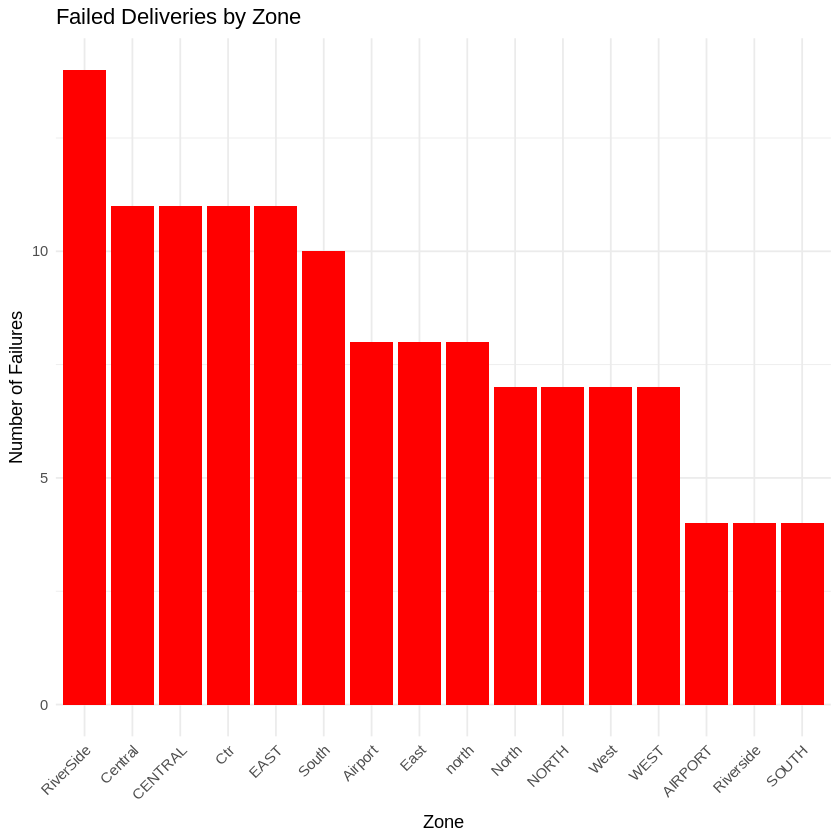

In [7]:
ggplot(result2, aes(x=reorder(pickup_zone, -failed), y=failed)) +
  geom_bar(stat='identity', fill='red') +
  labs(title='Failed Deliveries by Zone',
       x='Zone', y='Number of Failures') +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1))

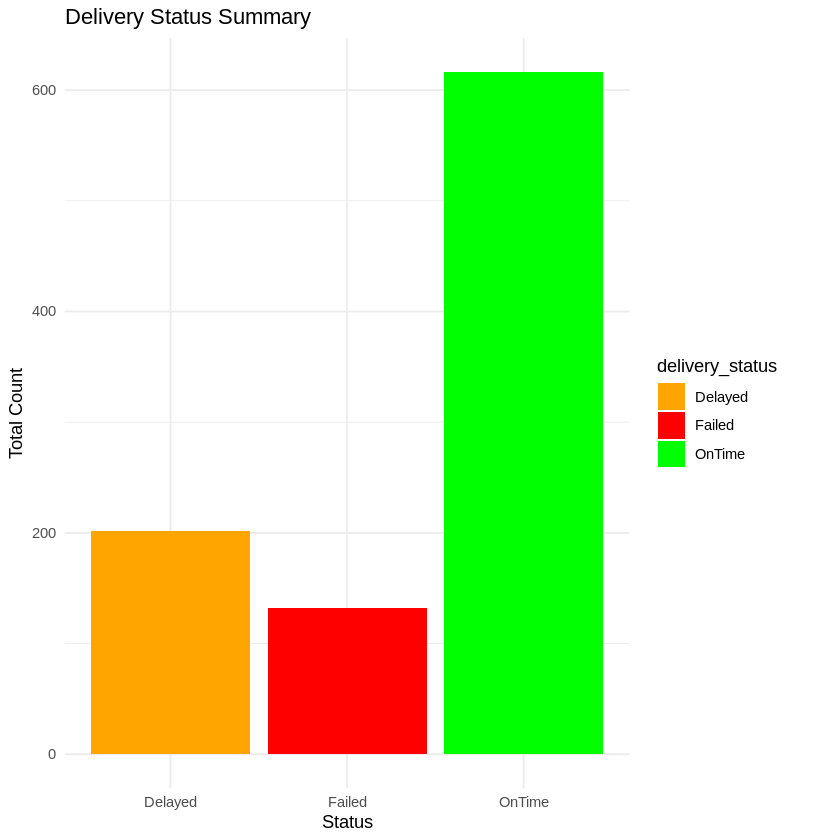

In [8]:
ggplot(result1, aes(x=delivery_status, y=total, fill=delivery_status)) +
  geom_bar(stat='identity') +
  scale_fill_manual(values=c('OnTime'='green', 'Delayed'='orange', 'Failed'='red')) +
  labs(title='Delivery Status Summary',
       x='Status', y='Total Count') +
  theme_minimal()

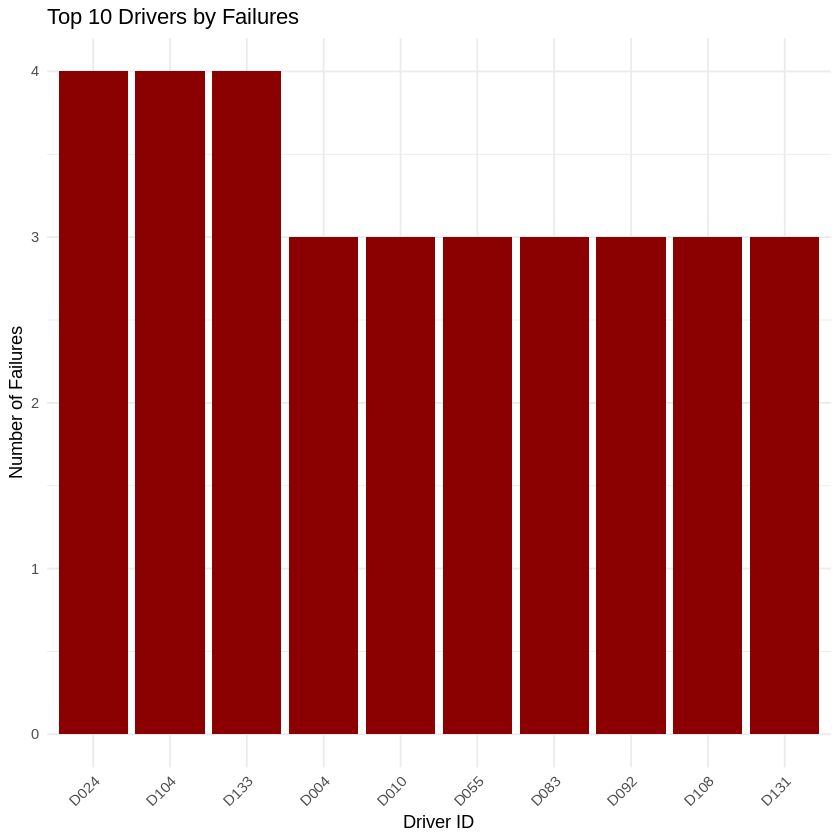

In [9]:
ggplot(result3, aes(x=reorder(driver_id, -failures), y=failures)) +
  geom_bar(stat='identity', fill='darkred') +
  labs(title='Top 10 Drivers by Failures',
       x='Driver ID', y='Number of Failures') +
  theme_minimal() +
  theme(axis.text.x = element_text(angle=45, hjust=1))